In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F 
import torch.backends.cudnn as cudnn

import torchvision
import torchvision.transforms as transforms

import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.pylab as plt2
import os

from models import *

# from resnet50 import ResNet50
# from resnet34 import ResNet34

from torch.optim.lr_scheduler import ReduceLROnPlateau




In [12]:
#Check GPU, connect to it if it is available 
device = ''
if torch.cuda.is_available():
	device = 'cuda'
	print("CUDA is available. GPU will be used for training.")
else:
	device = 'cpu'


BEST_ACCURACY = 0

# Preparing Data
print("==> Prepairing data ...")
#Transformation on train data
transform_train = transforms.Compose([
	transforms.RandomCrop(32, padding=4),
	transforms.RandomHorizontalFlip(),
	transforms.ToTensor(),
	transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2023, 0.1994, 0.2010)),
	])

#transformation on validation data
transform_validation = transforms.Compose([
	transforms.ToTensor(),
	transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
	])

#Download Train and Validation data and apply transformation
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
validation_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_validation)

#Put data into trainloader, specify batch_size
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
validation_loader = torch.utils.data.DataLoader(validation_data, batch_size=128, shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

#Function to show CIFAR images
def show_data(image):
	plt.imshow(np.transpose(image[0], (1, 2, 0)), interpolation='bicubic')
	plt.show()

#show_data(train_data[0])


#Need to import model a model
# model = ResNet50()
# model = ResNet34Cifar10(num_classes = 10)
model = ResNet34()
#model = CNN_batch()
#Pass model to GPU
model = model.to(device)
model.train()
optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)



length_train = len(train_data)
length_validation = len(validation_data)
#print(length_train)
#print(len(train_loader))
num_classes = 10

==> Prepairing data ...
Files already downloaded and verified
Files already downloaded and verified


In [19]:
#Training
def train(epochs):
	global BEST_ACCURACY
	dict = {'Train Loss':[], 'Train Acc':[], 'Validation Loss':[], 'Validation Acc':[]}
	for epoch in range(epochs):
		print("\nEpoch:", epoch+1, "/", epochs)
		cost = 0
		correct = 0
		total = 0
		woha = 0

		for i, (x,y) in enumerate(train_loader):
            
			woha += 1
			model.train()
			x, y = x.to(device), y.to(device)
			optimizer.zero_grad()
			yhat = model(x)
			yhat = yhat.reshape(-1, 10)
			loss = criterion(yhat, y)
			loss.backward()
			optimizer.step()
			cost += loss.item()

			_, yhat2 = torch.max(yhat.data, 1)
			correct += (yhat2 == y).sum().item()
			total += y.size(0)
			print("\nAcc:", correct/total, correct, "/", total)

		my_loss = cost/len(train_loader)
		my_accuracy = 100*correct/length_train

		dict['Train Loss'].append(my_loss)
		dict['Train Acc'].append(my_accuracy)

		print('Tain Loss:', my_loss)
		print('Train Accuracy:', my_accuracy,'%')


		cost = 0
		correct = 0

		with torch.no_grad():
			for x, y in validation_loader:
				x, y = x.to(device), y.to(device)
				model.eval()
				yhat = model(x)
				yhat = yhat.reshape(-1, 10)
				loss = criterion(yhat, y)
				cost += loss.item()
				
				_, yhat2 = torch.max(yhat.data, 1)
				correct += (yhat2 == y).sum().item()

		my_loss = cost/len(validation_loader)
		my_accuracy = 100*correct/length_validation

		dict['Validation Loss'].append(my_loss)
		dict['Validation Acc'].append(my_accuracy)

		print('Validation Loss:', my_loss)
		print('Validation Accuracy:', my_accuracy,'%')
        
		# Update the optimizer parameters
		optimizer.step()

		# Update the scheduler based on the validation accuracy
		scheduler.step(my_accuracy)

		# Zero the gradients
		optimizer.zero_grad()

		#Save the model if you get best accuracy on validation data
		if my_accuracy > BEST_ACCURACY:
			BEST_ACCURACY = my_accuracy
			print('Saving the model ...')
			model.eval()
			if not os.path.isdir('checkpoint'):
			    os.mkdir('checkpoint')
			torch.save(model.state_dict(), './checkpoint/resnet50.pth')

	print("TRAINING IS FINISHED !!!")
	return dict




Epoch: 1 / 70
Tain Loss: 2.0376024489500084
Train Accuracy: 26.648 %
Validation Loss: 1.6449706912040711
Validation Accuracy: 39.69 %
Saving the model ...

Epoch: 2 / 70
Tain Loss: 1.6375582303319658
Train Accuracy: 39.554 %
Validation Loss: 1.4736243784427643
Validation Accuracy: 45.68 %
Saving the model ...

Epoch: 3 / 70
Tain Loss: 1.4961928579272057
Train Accuracy: 45.186 %
Validation Loss: 1.3601812720298767
Validation Accuracy: 50.47 %
Saving the model ...

Epoch: 4 / 70
Tain Loss: 1.4022344898204415
Train Accuracy: 48.91 %
Validation Loss: 1.379337602853775
Validation Accuracy: 51.34 %
Saving the model ...

Epoch: 5 / 70
Tain Loss: 1.3127037748998525
Train Accuracy: 52.99 %
Validation Loss: 1.21883159160614
Validation Accuracy: 56.72 %
Saving the model ...

Epoch: 6 / 70
Tain Loss: 1.2417299200077445
Train Accuracy: 55.508 %
Validation Loss: 1.2310611069202424
Validation Accuracy: 55.69 %

Epoch: 7 / 70
Tain Loss: 1.1801959774932083
Train Accuracy: 57.974 %
Validation Loss: 1.1

Validation Loss: 0.6552756479382515
Validation Accuracy: 79.36 %

Epoch: 58 / 70
Tain Loss: 0.39994167004312786
Train Accuracy: 85.87 %
Validation Loss: 0.6603889632225036
Validation Accuracy: 79.52 %

Epoch: 59 / 70
Tain Loss: 0.3827792944348588
Train Accuracy: 86.46 %
Validation Loss: 0.7339966192841529
Validation Accuracy: 77.62 %

Epoch: 60 / 70
Tain Loss: 0.3796218478558015
Train Accuracy: 86.666 %
Validation Loss: 0.6824152168631553
Validation Accuracy: 79.14 %

Epoch: 61 / 70
Tain Loss: 0.3754176272421467
Train Accuracy: 86.632 %
Validation Loss: 0.691618738770485
Validation Accuracy: 79.03 %

Epoch: 62 / 70
Tain Loss: 0.37407904072683684
Train Accuracy: 86.68 %
Validation Loss: 0.6818434578180314
Validation Accuracy: 78.78 %

Epoch: 63 / 70
Tain Loss: 0.36743294888613176
Train Accuracy: 86.998 %
Validation Loss: 0.6688640236854553
Validation Accuracy: 79.67 %

Epoch: 64 / 70
Tain Loss: 0.3565463867722725
Train Accuracy: 87.318 %
Validation Loss: 0.6722684687376023
Validation Ac

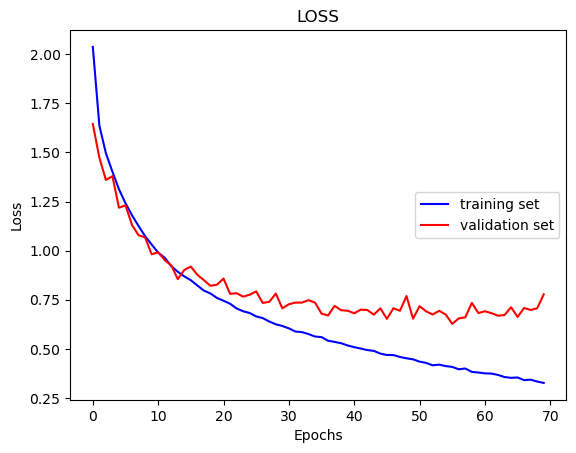

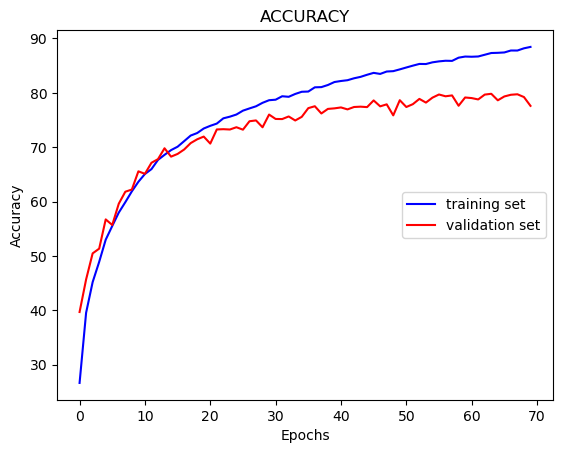

'\naxs[0].plot(results[\'Train Loss\'], \'b\', label = \'training loss\')\naxs[0].plot(results[\'Validation Loss\'], \'r\', label = \'validation loss\')\naxs[0].set_title("LOSS")\naxs[0].set(xlabel="Epochs", ylabel="Loss")\n\naxs[1].plot(results[\'Train Acc\'], \'b\', label = \'training accuracy\')\naxs[1].plot(results[\'Validation Acc\'], \'r\', label = \'validation accuracy\')\naxs[1].set_title("ACCURACY")\naxs[1].set(xlabel="Epochs", ylabel="Accuracy")\n\nfig.tight_layout()\nplt.legend()\nplt.show()\n'

In [4]:
#Start training
results = train(70)


plt.figure(1)
plt.plot(results['Train Loss'], 'b', label = 'training loss')
plt.plot(results['Validation Loss'], 'r', label = 'validation loss')
plt.title("LOSS")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['training set', 'validation set'], loc='center right')
plt.savefig('Loss_ResNet50.png', dpi=300, bbox_inches='tight')

plt.figure(2)
plt.plot(results['Train Acc'], 'b', label = 'training accuracy')
plt.plot(results['Validation Acc'], 'r', label = 'validation accuracy')
plt.title("ACCURACY")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['training set', 'validation set'], loc='center right')
plt.savefig('Accuracy_ResNet50.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

"""
axs[0].plot(results['Train Loss'], 'b', label = 'training loss')
axs[0].plot(results['Validation Loss'], 'r', label = 'validation loss')
axs[0].set_title("LOSS")
axs[0].set(xlabel="Epochs", ylabel="Loss")

axs[1].plot(results['Train Acc'], 'b', label = 'training accuracy')
axs[1].plot(results['Validation Acc'], 'r', label = 'validation accuracy')
axs[1].set_title("ACCURACY")
axs[1].set(xlabel="Epochs", ylabel="Accuracy")

fig.tight_layout()
plt.legend()
plt.show()
"""

In [6]:
torch.save(model.backbone.state_dict(), './Results/resnet34/backbone.pth')
torch.save(model.linear.state_dict(), './Results/resnet34/linear.pth')

In [20]:
#Start training
results = train(70)


plt.figure(1)
plt.plot(results['Train Loss'], 'b', label = 'training loss')
plt.plot(results['Validation Loss'], 'r', label = 'validation loss')
plt.title("LOSS")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['training set', 'validation set'], loc='center right')
plt.savefig('Loss_ResNet50.png', dpi=300, bbox_inches='tight')

plt.figure(2)
plt.plot(results['Train Acc'], 'b', label = 'training accuracy')
plt.plot(results['Validation Acc'], 'r', label = 'validation accuracy')
plt.title("ACCURACY")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['training set', 'validation set'], loc='center right')
plt.savefig('Accuracy_ResNet50.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

"""
axs[0].plot(results['Train Loss'], 'b', label = 'training loss')
axs[0].plot(results['Validation Loss'], 'r', label = 'validation loss')
axs[0].set_title("LOSS")
axs[0].set(xlabel="Epochs", ylabel="Loss")

axs[1].plot(results['Train Acc'], 'b', label = 'training accuracy')
axs[1].plot(results['Validation Acc'], 'r', label = 'validation accuracy')
axs[1].set_title("ACCURACY")
axs[1].set(xlabel="Epochs", ylabel="Accuracy")

fig.tight_layout()
plt.legend()
plt.show()
"""
torch.save(model.backbone.state_dict(), './Results/resnet34/backbone.pth')
torch.save(model.linear.state_dict(), './Results/resnet34/linear.pth')


Epoch: 1 / 70

Acc: 0.0703125 36 / 512

Acc: 0.09765625 100 / 1024

Acc: 0.11002604166666667 169 / 1536

Acc: 0.123046875 252 / 2048

Acc: 0.130859375 335 / 2560

Acc: 0.13444010416666666 413 / 3072

Acc: 0.13922991071428573 499 / 3584

Acc: 0.14404296875 590 / 4096

Acc: 0.1499565972222222 691 / 4608

Acc: 0.157421875 806 / 5120

Acc: 0.16548295454545456 932 / 5632

Acc: 0.17154947916666666 1054 / 6144

Acc: 0.17923677884615385 1193 / 6656

Acc: 0.1865234375 1337 / 7168

Acc: 0.191796875 1473 / 7680

Acc: 0.1959228515625 1605 / 8192

Acc: 0.19761029411764705 1720 / 8704

Acc: 0.2021484375 1863 / 9216

Acc: 0.20703125 2014 / 9728

Acc: 0.212109375 2172 / 10240

Acc: 0.216796875 2331 / 10752

Acc: 0.2215909090909091 2496 / 11264

Acc: 0.22528872282608695 2653 / 11776

Acc: 0.23055013020833334 2833 / 12288

Acc: 0.236171875 3023 / 12800

Acc: 0.23918269230769232 3184 / 13312

Acc: 0.24320023148148148 3362 / 13824

Acc: 0.24727957589285715 3545 / 14336

Acc: 0.25134698275862066 3732 / 14


Acc: 0.65078125 6664 / 10240

Acc: 0.6501116071428571 6990 / 10752

Acc: 0.650390625 7326 / 11264

Acc: 0.6501358695652174 7656 / 11776

Acc: 0.6504720052083334 7993 / 12288

Acc: 0.6503125 8324 / 12800

Acc: 0.6522686298076923 8683 / 13312

Acc: 0.6529947916666666 9027 / 13824

Acc: 0.6524832589285714 9354 / 14336

Acc: 0.6529498922413793 9695 / 14848

Acc: 0.6532552083333333 10034 / 15360

Acc: 0.6548639112903226 10394 / 15872

Acc: 0.6558837890625 10746 / 16384

Acc: 0.6560724431818182 11085 / 16896

Acc: 0.6578584558823529 11452 / 17408

Acc: 0.6581473214285715 11794 / 17920

Acc: 0.6587456597222222 12142 / 18432

Acc: 0.6597339527027027 12498 / 18944

Acc: 0.6602590460526315 12846 / 19456

Acc: 0.6597055288461539 13173 / 19968

Acc: 0.66015625 13520 / 20480

Acc: 0.6597751524390244 13850 / 20992

Acc: 0.6602492559523809 14198 / 21504

Acc: 0.6619276889534884 14573 / 22016

Acc: 0.6624644886363636 14924 / 22528

Acc: 0.6638020833333333 15294 / 23040

Acc: 0.6651664402173914 15666 


Acc: 0.7825349506578947 15225 / 19456

Acc: 0.7829527243589743 15634 / 19968

Acc: 0.78330078125 16042 / 20480

Acc: 0.7831078506097561 16439 / 20992

Acc: 0.7826450892857143 16830 / 21504

Acc: 0.7825672238372093 17229 / 22016

Acc: 0.7825372869318182 17629 / 22528

Acc: 0.7824652777777777 18028 / 23040

Acc: 0.7822690217391305 18424 / 23552

Acc: 0.7819564494680851 18817 / 24064

Acc: 0.7820638020833334 19220 / 24576

Acc: 0.7814492984693877 19605 / 25088

Acc: 0.78140625 20004 / 25600

Acc: 0.7820542279411765 20421 / 26112

Acc: 0.7819636418269231 20819 / 26624

Acc: 0.7819870283018868 21220 / 27136

Acc: 0.7822265625 21627 / 27648

Acc: 0.78203125 22022 / 28160

Acc: 0.7819126674107143 22419 / 28672

Acc: 0.782312225877193 22831 / 29184

Acc: 0.7823612607758621 23233 / 29696

Acc: 0.7826403601694916 23642 / 30208

Acc: 0.7829427083333333 24052 / 30720

Acc: 0.7830110143442623 24455 / 31232

Acc: 0.7826045866935484 24843 / 31744

Acc: 0.7824900793650794 25240 / 32256

Acc: 0.781982


Acc: 0.8309659090909091 23400 / 28160

Acc: 0.8311593191964286 23831 / 28672

Acc: 0.8316885964912281 24272 / 29184

Acc: 0.8316271551724138 24696 / 29696

Acc: 0.8319650423728814 25132 / 30208

Acc: 0.8314453125 25542 / 30720

Acc: 0.8317110655737705 25976 / 31232

Acc: 0.8321257560483871 26415 / 31744

Acc: 0.8322792658730159 26846 / 32256

Acc: 0.8323974609375 27276 / 32768

Acc: 0.8326322115384616 27710 / 33280

Acc: 0.8325639204545454 28134 / 33792

Acc: 0.8326725746268657 28564 / 34304

Acc: 0.8324333639705882 28982 / 34816

Acc: 0.8324841485507246 29410 / 35328

Acc: 0.8324776785714286 29836 / 35840

Acc: 0.8321687940140845 30251 / 36352

Acc: 0.832275390625 30681 / 36864

Acc: 0.8321650256849316 31103 / 37376

Acc: 0.832004856418919 31523 / 37888

Acc: 0.83234375 31962 / 38400

Acc: 0.8325452302631579 32396 / 38912

Acc: 0.8324624594155844 32819 / 39424

Acc: 0.8322816506410257 33238 / 39936

Acc: 0.8325009889240507 33673 / 40448

Acc: 0.8326416015625 34105 / 40960

Acc: 0.832


Acc: 0.8647795376712328 32322 / 37376

Acc: 0.8648912584459459 32769 / 37888

Acc: 0.8649739583333333 33215 / 38400

Acc: 0.865003083881579 33659 / 38912

Acc: 0.865031452922078 34103 / 39424

Acc: 0.8649839743589743 34544 / 39936

Acc: 0.8650860363924051 34991 / 40448

Acc: 0.8650146484375 35431 / 40960

Acc: 0.8646074459876543 35857 / 41472

Acc: 0.8644245426829268 36292 / 41984

Acc: 0.8645048945783133 36738 / 42496

Acc: 0.8646298363095238 37186 / 43008

Acc: 0.8644761029411765 37622 / 43520

Acc: 0.8645984738372093 38070 / 44032

Acc: 0.8643363864942529 38501 / 44544

Acc: 0.8643465909090909 38944 / 45056

Acc: 0.8642687851123596 39383 / 45568

Acc: 0.8639322916666666 39810 / 46080

Acc: 0.8639036744505495 40251 / 46592

Acc: 0.8638544497282609 40691 / 47104

Acc: 0.8638692876344086 41134 / 47616

Acc: 0.8637175864361702 41569 / 48128

Acc: 0.8637746710526316 42014 / 48640

Acc: 0.8636271158854166 42449 / 49152

Acc: 0.8636436855670103 42892 / 49664

Acc: 0.86372 43186 / 50000
Ta

...


Acc: 0.9833984375 22154 / 22528

Acc: 0.9832899305555556 22655 / 23040

Acc: 0.9830587635869565 23153 / 23552

Acc: 0.9832114361702128 23660 / 24064

Acc: 0.9831949869791666 24163 / 24576

Acc: 0.9832589285714286 24668 / 25088

Acc: 0.9831640625 25169 / 25600

Acc: 0.983187806372549 25673 / 26112

Acc: 0.9832481971153846 26178 / 26624

Acc: 0.9832694575471698 26682 / 27136

Acc: 0.9833260995370371 27187 / 27648

Acc: 0.9833451704545455 27691 / 28160

Acc: 0.9832240513392857 28191 / 28672

Acc: 0.9830043859649122 28688 / 29184

Acc: 0.9829943426724138 29191 / 29696

Acc: 0.9829515360169492 29693 / 30208

Acc: 0.9830729166666666 30200 / 30720

Acc: 0.9829021516393442 30698 / 31232

Acc: 0.9829889112903226 31204 / 31744

Acc: 0.9828869047619048 31704 / 32256

Acc: 0.98297119140625 32210 / 32768

Acc: 0.9829026442307692 32711 / 33280

Acc: 0.9828361742424242 33212 / 33792

Acc: 0.9828299906716418 33715 / 34304

Acc: 0.9827665441176471 34216 / 34816

Acc: 0.9825917119565217 34713 / 35328




Acc: 0.9819584216101694 29663 / 30208

Acc: 0.9819986979166667 30167 / 30720

Acc: 0.9819415983606558 30668 / 31232

Acc: 0.9817918346774194 31166 / 31744

Acc: 0.9817088293650794 31666 / 32256

Acc: 0.981781005859375 32171 / 32768

Acc: 0.9817307692307692 32672 / 33280

Acc: 0.9817708333333334 33176 / 33792

Acc: 0.9816056436567164 33673 / 34304

Acc: 0.9814165900735294 34169 / 34816

Acc: 0.9814594655797102 34673 / 35328

Acc: 0.9815290178571429 35178 / 35840

Acc: 0.9814040492957746 35676 / 36352

Acc: 0.9813368055555556 36176 / 36864

Acc: 0.9813784246575342 36680 / 37376

Acc: 0.9814453125 37185 / 37888

Acc: 0.981484375 37689 / 38400

Acc: 0.9813939144736842 38188 / 38912

Acc: 0.9812804383116883 38686 / 39424

Acc: 0.9812199519230769 39186 / 39936

Acc: 0.9810868275316456 39683 / 40448

Acc: 0.9810302734375 40183 / 40960

Acc: 0.9809027777777778 40680 / 41472

Acc: 0.9808260289634146 41179 / 41984

Acc: 0.9808452560240963 41682 / 42496

Acc: 0.9808175223214286 42183 / 43008

Ac


Acc: 0.9839381167763158 38287 / 38912

Acc: 0.9840198863636364 38794 / 39424

Acc: 0.9840244391025641 39298 / 39936

Acc: 0.9840041534810127 39801 / 40448

Acc: 0.983984375 40304 / 40960

Acc: 0.9839891975308642 40808 / 41472

Acc: 0.9838986280487805 41308 / 41984

Acc: 0.9840220256024096 41817 / 42496

Acc: 0.9840029761904762 42320 / 43008

Acc: 0.983984375 42823 / 43520

Acc: 0.9839662063953488 43326 / 44032

Acc: 0.9840158045977011 43832 / 44544

Acc: 0.9839089133522727 44331 / 45056

Acc: 0.9837824789325843 44829 / 45568

Acc: 0.9837456597222223 45331 / 46080

Acc: 0.9837311126373627 45834 / 46592

Acc: 0.9836319633152174 46333 / 47104

Acc: 0.9836189516129032 46836 / 47616

Acc: 0.9835438829787234 47336 / 48128

Acc: 0.9834909539473684 47837 / 48640

Acc: 0.9834391276041666 48338 / 49152

Acc: 0.983509181701031 48845 / 49664

Acc: 0.98352 49176 / 50000
Tain Loss: 0.045998952826675106
Train Accuracy: 98.352 %
Validation Loss: 0.5357826636731624
Validation Accuracy: 88.36 %

Epoch:


Acc: 0.9845850134408602 46882 / 47616

Acc: 0.9845204454787234 47383 / 48128

Acc: 0.9844777960526315 47885 / 48640

Acc: 0.9844970703125 48390 / 49152

Acc: 0.9845360824742269 48896 / 49664

Acc: 0.98454 49227 / 50000
Tain Loss: 0.04477458095596153
Train Accuracy: 98.454 %
Validation Loss: 0.47916787371039393
Validation Accuracy: 89.21 %

Epoch: 51 / 70

Acc: 0.982421875 503 / 512

Acc: 0.986328125 1010 / 1024

Acc: 0.9869791666666666 1516 / 1536

Acc: 0.984375 2016 / 2048

Acc: 0.9859375 2524 / 2560

Acc: 0.9847005208333334 3025 / 3072

Acc: 0.9827008928571429 3522 / 3584

Acc: 0.982177734375 4023 / 4096

Acc: 0.9830729166666666 4530 / 4608

Acc: 0.9830078125 5033 / 5120

Acc: 0.9831321022727273 5537 / 5632

Acc: 0.9833984375 6042 / 6144

Acc: 0.9837740384615384 6548 / 6656

Acc: 0.984375 7056 / 7168

Acc: 0.9850260416666666 7565 / 7680

Acc: 0.9849853515625 8069 / 8192

Acc: 0.9854090073529411 8577 / 8704

Acc: 0.9852430555555556 9080 / 9216

Acc: 0.985094572368421 9583 / 9728

Acc

KeyboardInterrupt: 

In [ ]:
# Save the layers except the linear layer
layer_dict = {}
for name, layer in model.named_children():
    if name != 'linear':
        layer_dict[name] = layer.state_dict()

# Save the linear layer separately
linear_dict = model.linear.state_dict()

torch.save(layer_dict, './Results/resnet34/backbone_34_new.pth')
torch.save(linear, './Results/resnet34/linear_34_new.pth')